In [17]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 0
true["label"] = 1

data = pd.concat([fake, true]).sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,Pennsylvania glitches did not cause ballots to...,WASHINGTON (Reuters) - Election officials in t...,politicsNews,"November 8, 2016",1
1,Explosion kills three Chadian U.N. peacekeeper...,ABIDJAN (Reuters) - Three United Nations soldi...,worldnews,"October 26, 2017",1
2,Is the United States of America a Liberal Demo...,21st Century Wire says Does the American ideal...,US_News,"June 8, 2017",0
3,Trump’s ‘Condolences’ To Grieving Star Were A...,"Trump has no compassion, and he has no empathy...",News,"October 25, 2016",0
4,"Trump's remarks on gun rights, Clinton unleash...","WILMINGTON, N.C. (Reuters) - Republican presid...",politicsNews,"August 9, 2016",1


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    return text

data["text"] = data["text"].apply(clean_text)

In [5]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 300

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [7]:
cnn_model = Sequential([
    Embedding(5000, 128, input_length=max_len),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

cnn_model.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 115s 222ms/step - accuracy: 0.9654 - loss: 0.0932 - val_accuracy: 0.9900 - val_loss: 0.0258
Epoch 2/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 138s 214ms/step - accuracy: 0.9970 - loss: 0.0103 - val_accuracy: 0.9942 - val_loss: 0.0180
Epoch 3/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 141s 213ms/step - accuracy: 0.9999 - loss: 0.0010 - val_accuracy: 0.9950 - val_loss: 0.0187


In [8]:
lstm_model = Sequential([
    Embedding(5000, 128, input_length=max_len),
    LSTM(128),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_model.fit(X_train_pad, y_train, epochs=3, batch_size=64, validation_split=0.1)

Epoch 1/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 316s 619ms/step - accuracy: 0.9458 - loss: 0.1506 - val_accuracy: 0.9683 - val_loss: 0.0942
Epoch 2/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 330s 635ms/step - accuracy: 0.9673 - loss: 0.0954 - val_accuracy: 0.9602 - val_loss: 0.1191
Epoch 3/3
506/506 ━━━━━━━━━━━━━━━━━━━━ 313s 618ms/step - accuracy: 0.9734 - loss: 0.0763 - val_accuracy: 0.9780 - val_loss: 0.0705


In [9]:
cnn_preds = (cnn_model.predict(X_test_pad) > 0.5).astype(int)
lstm_preds = (lstm_model.predict(X_test_pad) > 0.5).astype(int)

print("CNN Accuracy:", accuracy_score(y_test, cnn_preds))
print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 38s 133ms/step
CNN Accuracy: 0.9926503340757238
LSTM Accuracy: 0.978173719376392


In [18]:
print(classification_report(y_test, cnn_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4701
           1       0.99      0.99      0.99      4279

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [19]:
print(classification_report(y_test, lstm_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4701
           1       0.99      0.97      0.98      4279

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



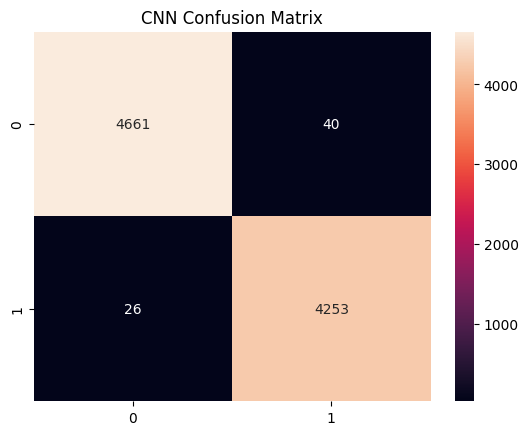

In [10]:
cm = confusion_matrix(y_test, cnn_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("CNN Confusion Matrix")
plt.show()

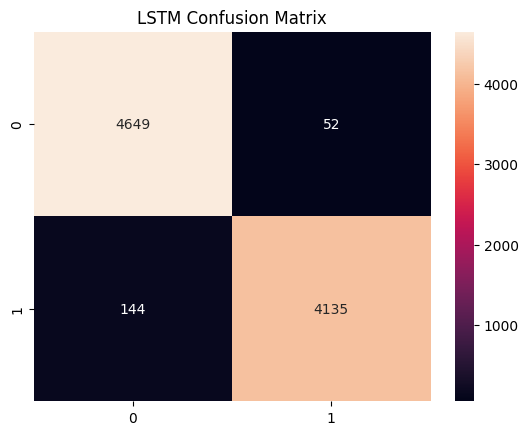

In [15]:
cm = confusion_matrix(y_test, lstm_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("LSTM Confusion Matrix")
plt.show()

In [11]:
cnn_model.save("cnn_model.h5")
lstm_model.save("lstm_model.h5")

pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))